In [65]:
import sys
import os

sys.path.append(os.path.abspath("../../.."))

from core.split_samples import get_splited_data
from scipy.linalg import LinAlgError
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential


import matplotlib.pyplot as plt
import pandas as pd


import numpy as np


import seaborn as sns
import pickle

#     Consolidando um _pipeline_ simples para exportar

### **Etapa 1: Análise Inicial e Preparação**

- Dados a Utilizar: DataFrame Total.
- Objetivo Principal: Garantir a saúde, integridade e o entendimento básico dos dados brutos antes de qualquer divisão.


### 1.1 Carregando os dados

In [129]:
data = pd.read_excel('../../../data/datasets/base_vertical/intermediate/HS_agregado_sem_cod_20windows_normal_sopro_binary_kalman_1.xlsx')
data = data.drop(columns=['window_id'])


## **Etapa 2: Separação dos Dados** 

Criar as partições de treino e teste, isolando o conjunto de teste para garantir uma avaliação final 100% imparcial.

### 2.1 Definir _features_ (X) e alvo (y)

Aqui precisaremos tomar cuidado com o vazamento de dados por agrupamento (_data leakage due to grouping_). Se uma janela dde um determinado áudio está no treino e outra do mesmo áudio está no teste, o modelo "trapaceia". Ele aprende sobre o determinado áudio no treino e depois é testado em um dado muito similar (outra janela do mesmo áudio), o que leva a uma performance artificialmente alta e a um otimismo irrealista.

Portanto, deve-se pensar em uma divisão baseada em grupos.
A solução é garantir que a unidade de separação não seja a janela (a linha do dataframe), mas sim o áudio de origem (o grupo). Todas as 20 janelas de um determinado áudio devem pertencer juntas ao conjunto de treino ou juntas ao conjunto de teste. Nunca separadas.

O Scikit-learn tem ferramentas específicas para isso. As principais são `GroupShuffleSplit` e `GroupKFold`.

In [114]:
X, y = get_splited_data(data, 'Heart Sound Type')

#### 2.2 Executar a Divisão

In [115]:
groups = X['Heart Sound ID']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

"""
O .split() gera os ÍNDICES de treino e teste.
Precisamos usá-lo com next() porque ele é um gerador.
"""
train_idx, test_idx = next(gss.split(X, y, groups=groups))

# usando os índices para criar os df's
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]

Verificação: é importante verificar que não há nenhum _Heart Sound ID_ que apareça tanto em `X_train` quanto em `X_test`.

In [116]:
print(f"Audios no treino: {len(X_train['Heart Sound ID'].unique())}")
print(f"Audios no teste: {len(X_test['Heart Sound ID'].unique())}")

train_audios = set(X_train['Heart Sound ID'].unique())
test_audios = set(X_test['Heart Sound ID'].unique())
print("Audios vazados (interseção):", train_audios.intersection(
    test_audios))  # <===== Deve ser um conjunto vazio!

Audios no treino: 17
Audios no teste: 5
Audios vazados (interseção): set()


In [107]:
len(X_train['Heart Sound ID'].unique())

17

#### 2.3 Salvando os dados por segurança

In [ ]:

data_to_save = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test
}
with open('../../../data/datasets/base_vertical/processed/train_test_sets_normal_vs_sopro.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)


""" 
Para carregar os dados:

with open('../../../data/datasets/base_vertical/processed/train_test_sets_normal_vs_sopro.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

X_train_ = loaded_data['X_train']
X_test_ = loaded_data['X_test']
y_train_ = loaded_data['y_train']
y_test_ = loaded_data['y_test']
"""

" \nPara carregar os dados:\n\nwith open('../../../datasets/base_vertical/processed/train_test_sets.pkl', 'rb') as f:\n    loaded_data = pickle.load(f)\n\nX_train_ = loaded_data['X_train']\nX_test_ = loaded_data['X_test']\ny_train_ = loaded_data['y_train']\ny_test_ = loaded_data['y_test']\n"

## Correlação entre _features_

Aqui deve-se investigar as relações entre asfeatures e a variável alvo para gerar hipóteses e guiar a modelagem.

- Criar uma matriz de correlação para ver quais _features_ estão fortemente relacionadas entre si. _Features_ com correlação muito alta (ex: >0.9 ou < -0.9>) são redundantes e pode-se considerar remover uma delas.
- Ferramenta: `X_train.corr()`, `seaborn.heatmap(X_train.corr())`

In [89]:
X_train_numeric = X_train.select_dtypes(include='number')

<Axes: >

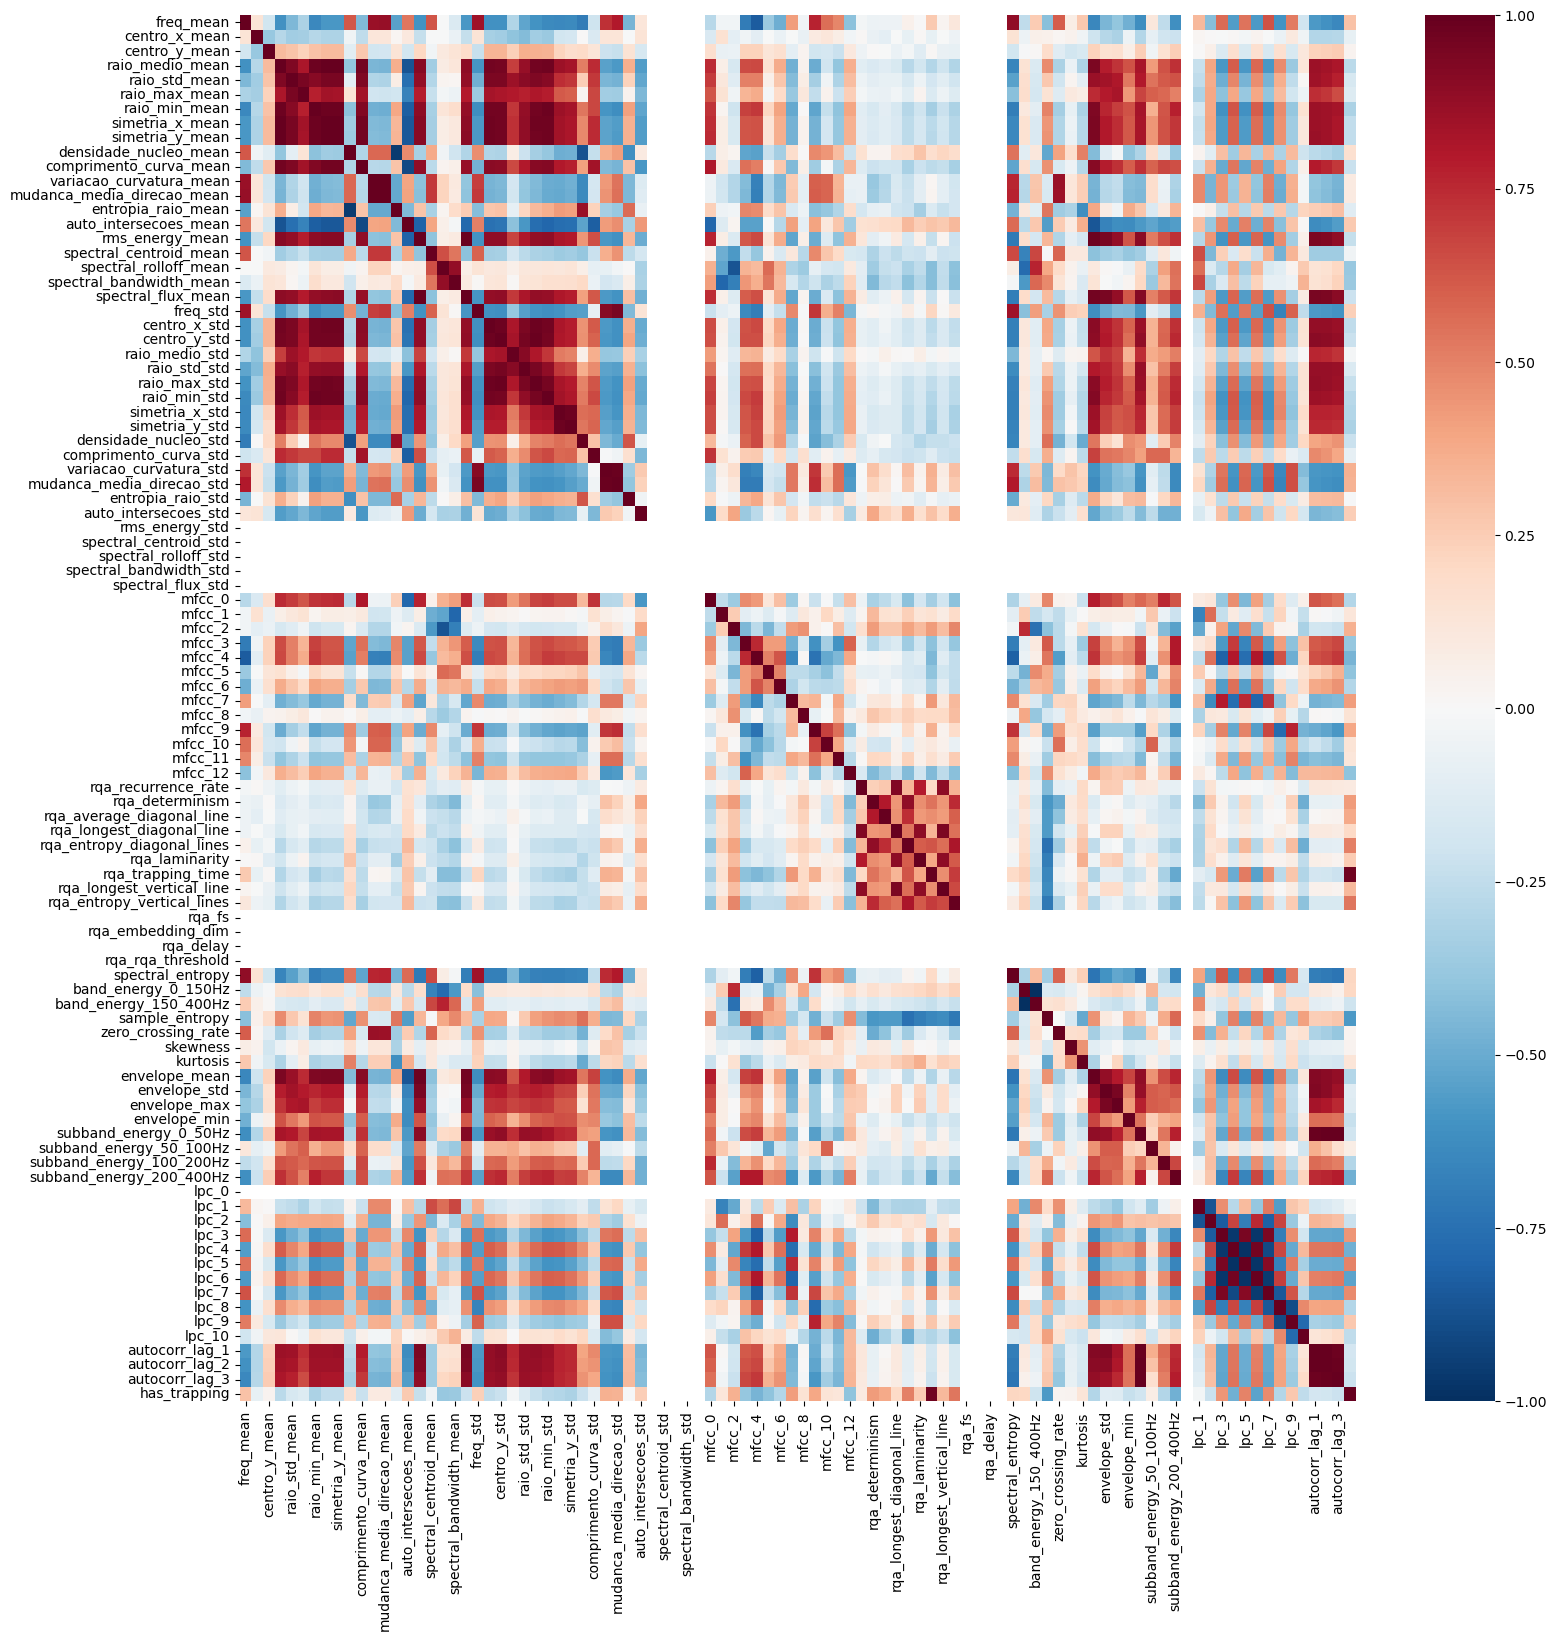

In [90]:
fig, ax = plt.subplots(figsize=(18, 18))

sns.heatmap(X_train_numeric.corr(),
            fmt='.2f',
            ax=ax,
            cmap="RdBu_r",
            vmin=-1,
            vmax=1)

O heatmap mostra claramente a existência de multicolinearidade, ou seja, grupos de features que estão fortemente correlacionadas entre si.

Manter features altamente correlacionadas é problemático por algumas razões:

- Redundância: O modelo não aprende nada de novo. Se duas features são 95% correlacionadas, elas estão essencialmente dizendo a mesma coisa.
- Instabilidade do Modelo: Alguns algoritmos (como regressões lineares) podem se tornar instáveis. Modelos de árvore (como o Random Forest) são mais robustos a isso, mas a redundância pode enviesar a interpretação da "importância das features".
- Maldição da Dimensionalidade: Manter features desnecessárias aumenta a complexidade do problema sem adicionar informação útil, podendo até piorar a performance do modelo.



### Seleção de _features_ por correlação e informação mútua

In [ ]:
print("1. Separando features numéricas e categóricas...")
numeric_cols = X_train_numeric.columns.tolist()
categorical_cols = X_train.select_dtypes(
    include=['object', 'category']).columns.tolist()
print(
    f"Encontradas {len(numeric_cols)} features numéricas e {len(categorical_cols)} categóricas.")


print("\n2. Calculando a matriz de correlação...")
corr_matrix = X_train_numeric.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))


print("\n3. Preparando dados para cálculo da Informação Mútua...")
X_train_encoded_for_mi = X_train.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_train_encoded_for_mi[col] = le.fit_transform(X_train_encoded_for_mi[col])

le_y = LabelEncoder()
y_train_encoded = le_y.fit_transform(y_train)

print("Calculando a Informação Mútua para todas as features...")
mi_scores = mutual_info_classif(
    X_train_encoded_for_mi, y_train_encoded, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train.columns)


print("\n4. Identificando features redundantes para remover...")
threshold = 0.80
to_drop = set()  # Usar um set é mais eficiente para evitar duplicatas

for col in upper_triangle.columns:
    correlated_features = upper_triangle.index[upper_triangle[col] > threshold].tolist(
    )
    for row in correlated_features:
        if mi_series[row] < mi_series[col]:
            to_drop.add(row)
        else:
            to_drop.add(col)

to_drop = list(to_drop)

X_train_reduced = X_train.drop(columns=to_drop)

print(
    f"\nNúmero de features removidas com critério de utilidade: {len(to_drop)}")
print("Features removidas:", sorted(to_drop))

1. Separando features numéricas e categóricas...
Encontradas 96 features numéricas e 3 categóricas.

2. Calculando a matriz de correlação...

3. Preparando dados para cálculo da Informação Mútua...
Calculando a Informação Mútua para todas as features...

4. Identificando features redundantes para remover...

Número de features removidas com critério de utilidade: 50
Features removidas: ['auto_intersecoes_mean', 'autocorr_lag_1', 'autocorr_lag_2', 'autocorr_lag_3', 'band_energy_150_400Hz', 'centro_x_std', 'centro_y_std', 'comprimento_curva_mean', 'comprimento_curva_std', 'densidade_nucleo_std', 'entropia_raio_mean', 'envelope_mean', 'envelope_std', 'freq_mean', 'freq_std', 'has_trapping', 'lpc_2', 'lpc_3', 'lpc_4', 'lpc_5', 'lpc_6', 'lpc_7', 'lpc_9', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mudanca_media_direcao_mean', 'mudanca_media_direcao_std', 'raio_max_mean', 'raio_max_std', 'raio_medio_mean', 'raio_medio_std', 'raio_min_mean', 'raio_min_std', 'raio_std_mean', 'raio_std_std', 'rms_energy_mea

In [92]:
""" Outras colunas para remover que podem enviesar o modelo caso permaneçam como atributos"""
others_columns_to_remove = ['Gender', 'Location']
to_drop.extend(others_columns_to_remove)

### Deletando as _features_ contínuas de valores constantes, pois não apresentam qualquer variabilidade.

In [ ]:
cols_constantes = [
    col for col in X_train_reduced.columns if X_train_reduced[col].nunique() == 1]

print("Colunas com valor constante:", cols_constantes)


#X_train_reduced = X_train_reduced.drop(columns=cols_constantes, errors='ignore')


Colunas com valor constante: ['rms_energy_std', 'spectral_centroid_std', 'spectral_rolloff_std', 'spectral_bandwidth_std', 'spectral_flux_std', 'rqa_fs', 'rqa_embedding_dim', 'rqa_delay', 'rqa_rqa_threshold', 'lpc_0']


### Criando o Pipeline reutilizável

In [ ]:
import pandas as pd
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from xgboost import XGBClassifier


colunas_a_remover = to_drop + cols_constantes

df_original = pd.read_excel(
    '../../../data/datasets/base_vertical/intermediate/HS_agregado_sem_cod_20windows_normal_sopro_binary_kalman_1.xlsx')


X = df_original.drop(columns=['Heart Sound Type'])
y_true = df_original['Heart Sound Type']

# --- 2. DEFINIÇÃO DO PIPELINE AUTOCONTIDO ---
todas_as_features = X.drop(columns='Heart Sound ID').columns.tolist()
"""criamos as listas de colunas que queremos MANTER"""
features_a_manter = [
    col for col in todas_as_features if col not in colunas_a_remover]
"""Separamos as colunas que sobraram em numéricas e categóricas"""
num_cols_final = [
    col for col in features_a_manter if X[col].dtype in ['int64', 'float64']]
cat_cols_final = [col for col in features_a_manter if X[col].dtype == 'object']

"""Criamos o pré-processador que sabe quais colunas usar e quais descartar"""
preprocessor_completo = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_final),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_final)
    ],
    remainder='drop'  # OPÇÃO PADRÃO E A CHAVE!
                      # Colunas não listadas acima serão AUTOMATICAMENTE descartadas.
)

""" pipeline final"""
pipeline_autocontido = Pipeline(steps=[
    ('preprocessor', preprocessor_completo),
    ('classifier', XGBClassifier(n_estimators=100,
     use_label_encoder=False, eval_metric='mlogloss'))
])

"""LabelEncoder ainda é necessário para o 'y', e precisa ser salvo"""
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_true)


# --- 3. TREINAMENTO FINAL E SALVAMENTO ---
print("Treinando o pipeline autocontido com os dados brutos...")
"""passamos o DataFrame 'X', com TODAS as colunas.
O pipeline vai cuidar de tudo internamente."""
pipeline_autocontido.fit(X, y_encoded)
print("Treinamento concluído!")

"""salnvando o pipeline que agora contém toda a lógica"""
joblib.dump(pipeline_autocontido, 'meu_pipeline_completo.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
print("Pipeline autocontido salvo!")


Treinando o pipeline autocontido com os dados brutos...
Treinamento concluído!
Pipeline autocontido salvo!


c:\Users\pflss\miniconda3\envs\sensory-translation\lib\site-packages\xgboost\training.py:183: UserWarning: [20:12:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# --- 4. USO EM NOVOS DADOS ---
modelo_final = joblib.load('meu_pipeline_completo.pkl')

X_novo_bruto = pd.read_excel(
    '../../../data/datasets/base_vertical/intermediate/HS_agregado_sem_cod_20windows_normal_sopro_binary_kalman_2.xlsx')

predicao = modelo_final.predict(X_novo_bruto)
print(f"\nPredição no novo dado bruto: {predicao}")


Predição no novo dado bruto: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 0 0 0 1 0
 0 1 1 1 0 0 1 0 0 1 1 0 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [125]:
X_novo, y_novo = get_splited_data(X_novo_bruto, 'Heart Sound Type')

Fazendo predições no conjunto de teste...

--- MÉTRICAS DE PERFORMANCE NO CONJUNTO DE TESTE ---
                precision    recall  f1-score   support

        Normal       0.92      0.99      0.96       242
Sopro Cardíaco       0.99      0.92      0.95       242

      accuracy                           0.95       484
     macro avg       0.96      0.95      0.95       484
  weighted avg       0.96      0.95      0.95       484


--- MATRIZ DE CONFUSÃO NO CONJUNTO DE TESTE ---


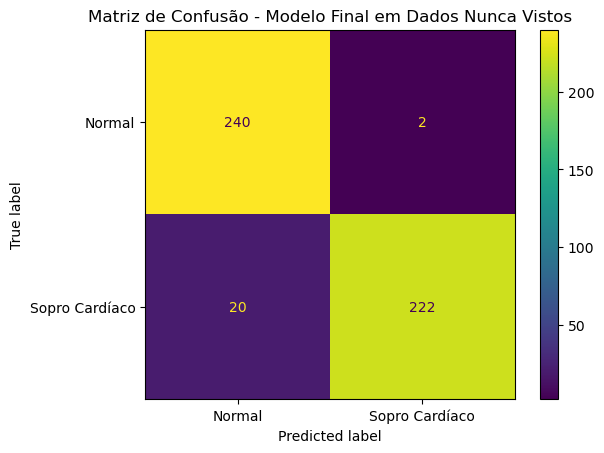

In [ ]:
import joblib
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

modelo_final = joblib.load('meu_pipeline_completo.pkl') 
label_encoder = joblib.load('label_encoder.pkl')


# --- PREDIÇÃO E AVALIAÇÃO ---
print("Fazendo predições no conjunto de teste...")

y_pred_encoded = modelo_final.predict(X_novo)

y_pred_labels = label_encoder.inverse_transform(y_pred_encoded)

print("\n--- MÉTRICAS DE PERFORMANCE NO CONJUNTO DE TESTE ---")
print(classification_report(y_novo, y_pred_labels))

print("\n--- MATRIZ DE CONFUSÃO NO CONJUNTO DE TESTE ---")
ConfusionMatrixDisplay.from_predictions(
    y_novo,
    y_pred_labels,
    cmap='viridis'
)
plt.title("Matriz de Confusão - Modelo Final em Dados Nunca Vistos")
plt.show()